# Experiment - Does the JFDS Equation Actually Matter?
### Adaptive-λ JScore vs. Plain Relevance-Only Top-K, on MovieLens 1M

**What this notebook tests**

The original implementation (`jfds_implementation.ipynb`) swept λ_f and λ_d as
**fixed constants per run** to find a single best static configuration.

This notebook tests a different question: *what if λ_f and λ_d are not fixed
at all, but change as the list is built?* Specifically, we make them an
**iterative variable tied to list position k**:

- Early in the list (k small) → stay **utility-heavy** (trust relevance).
- Later in the list (k large) → shift weight **toward fairness and diversity**
  (the list already has its "obvious" picks, so spend the remaining slots
  correcting for popularity bias and redundancy).

We then compare this **adaptive-λ JScore** against a **plain Top-K by
relevance only** (i.e. `λ_f = λ_d = 0` for every slot — the equation switched
off entirely) to see what difference the JFDS machinery actually makes:

1. Are the recommended lists themselves different (item overlap)?
2. Do the fairness / diversity / JFDS metrics actually move?
3. What's given up on relevance/utility to get there?

> **No results are computed or interpreted here.** All cells are ready to
> run — you execute and analyse.


---
## Part 0 — Recap: The JFDS Equation

$$\text{JScore}(i,\,S) = \underbrace{(1-\lambda_f-\lambda_d)}_{\lambda_u}\cdot\text{rel}(i) \;+\; \lambda_f\cdot\text{fair\_boost}(i) \;+\; \lambda_d\cdot\text{div}(i,\,S)$$

$$\text{JFDS} = \text{ItemFairness} \times \text{AggregateDiversity}$$

In the original notebook, λ_f and λ_d were **constants for an entire run**
(swept across a grid, e.g. λ_f=0.2, λ_d=0.1 for the whole top-10 list).

### The adaptive-λ schedule used in this experiment

For a list of length $K$, at greedy step $k$ (0-indexed, $k = 0, \dots, K-1$),
define a progress fraction:

$$t_k = \frac{k}{K-1} \qquad (t_0 = 0 \text{ at the first slot}, \; t_{K-1} = 1 \text{ at the last slot})$$

and let λ_f, λ_d **grow with $t_k$** from a low starting weight to a high
ending weight:

$$\lambda_f(k) = \lambda_f^{start} + \big(\lambda_f^{end} - \lambda_f^{start}\big)\cdot t_k^{\,p}$$

$$\lambda_d(k) = \lambda_d^{start} + \big(\lambda_d^{end} - \lambda_d^{start}\big)\cdot t_k^{\,p}$$

with $\lambda_u(k) = 1 - \lambda_f(k) - \lambda_d(k)$ recomputed every step
(simplex constraint still holds at every k). The exponent $p$ controls the
shape of the ramp ($p=1$ linear, $p>1$ back-loaded, $p<1$ front-loaded).

This is exactly what's meant by "λ as an iterative variable that changes
with the configuration of f and d as the list is built" — at every greedy
step the weights are recomputed before scoring candidates.


---
## Part 1 — Setup & Data Loading

Same loading logic as the original implementation notebook, pointed at the
uploaded `.dat` files.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded ✓')


Libraries loaded ✓


In [2]:
DATA_DIR = '../dataset/movie_lens'

ratings = pd.read_csv(
    f'{DATA_DIR}/ratings.dat', sep='::', engine='python', header=None,
    names=['UserID', 'MovieID', 'Rating', 'Timestamp']
)
movies = pd.read_csv(
    f'{DATA_DIR}/movies.dat', sep='::', engine='python', header=None,
    names=['MovieID', 'Title', 'Genres'], encoding='latin-1'
)
users = pd.read_csv(
    f'{DATA_DIR}/users.dat', sep='::', engine='python', header=None,
    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip']
)

print(f'Ratings : {len(ratings):,}')
print(f'Movies  : {len(movies):,}')
print(f'Users   : {ratings["UserID"].nunique():,}')
print(f'Matrix density: {len(ratings) / (ratings["UserID"].nunique() * movies["MovieID"].nunique()) * 100:.4f}%')

print('\n--- Ratings sample ---')
print(ratings.head(3).to_string(index=False))
print('\n--- Movies sample ---')
print(movies.head(3).to_string(index=False))


Ratings : 1,000,209
Movies  : 3,883
Users   : 6,040
Matrix density: 4.2647%

--- Ratings sample ---
 UserID  MovieID  Rating  Timestamp
      1     1193       5  978300760
      1      661       3  978302109
      1      914       3  978301968

--- Movies sample ---
 MovieID                   Title                       Genres
       1        Toy Story (1995)  Animation|Children's|Comedy
       2          Jumanji (1995) Adventure|Children's|Fantasy
       3 Grumpier Old Men (1995)               Comedy|Romance


In [3]:
# ── Item-level exposure, popularity, genre encoding, relevance ─────────────
item_stats = (
    ratings.groupby('MovieID')
    .agg(n_ratings=('Rating','count'), mean_rating=('Rating','mean'), n_users=('UserID','nunique'))
    .reset_index()
)

pop_threshold = item_stats['n_ratings'].quantile(0.80)
item_stats['is_popular'] = (item_stats['n_ratings'] >= pop_threshold).astype(int)

total_ratings = item_stats['n_ratings'].sum()
popular_share = item_stats.loc[item_stats['is_popular']==1,'n_ratings'].sum() / total_ratings * 100

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} ratings')
print(f'Popular items  : {item_stats["is_popular"].sum():,}  ({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche items    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular items receive {popular_share:.1f}% of all ratings (80/20 rule)')

# Genre one-hot (for cosine diversity)
movies_exp = movies.copy()
movies_exp['Genre'] = movies_exp['Genres'].str.split('|')
movies_exp = movies_exp.explode('Genre')
genre_dummies = (
    pd.get_dummies(movies_exp[['MovieID','Genre']], columns=['Genre'])
    .groupby('MovieID').max()
)
genre_dummies.columns = [c.replace('Genre_','') for c in genre_dummies.columns]
genre_cols = genre_dummies.columns.tolist()
item_stats = item_stats.merge(genre_dummies, on='MovieID', how='left')

# Bayesian-smoothed relevance → [0,1]
global_mean = ratings['Rating'].mean()
m = 10
item_stats['rel'] = (
    (item_stats['n_ratings'] * item_stats['mean_rating'] + m * global_mean)
    / (item_stats['n_ratings'] + m)
)
item_stats['rel'] = (
    (item_stats['rel'] - item_stats['rel'].min())
    / (item_stats['rel'].max() - item_stats['rel'].min())
)

print(f'\nGenre dimensions : {len(genre_cols)}')
print(f'Relevance range  : [{item_stats["rel"].min():.4f}, {item_stats["rel"].max():.4f}]')
print('Data preparation complete ✓')

# Pre-compute L2-normalised genre matrix
item_stats_idx = item_stats.reset_index(drop=True)
genre_mat      = item_stats_idx[genre_cols].fillna(0).values.astype(float)
norms          = np.linalg.norm(genre_mat, axis=1, keepdims=True)
norms[norms==0] = 1
genre_mat_norm = genre_mat / norms
mid_to_idx     = {mid:idx for idx,mid in enumerate(item_stats_idx['MovieID'])}

print(f'Genre matrix shape : {genre_mat_norm.shape}')


Popularity threshold (80th pct) : 429 ratings
Popular items  : 743  (20.0% of catalogue)
Niche items    : 2,963
Popular items receive 65.2% of all ratings (80/20 rule)

Genre dimensions : 18
Relevance range  : [0.0000, 1.0000]
Data preparation complete ✓
Genre matrix shape : (3706, 18)


---
## Part 2 — Two Selection Strategies

### Strategy A — Plain Top-K (relevance only, equation switched OFF)

This is the "not using it" baseline: simple ranking by `rel(i)` alone. No
fairness boost, no diversity term, no λ at all. Equivalent to setting
λ_f = λ_d = 0 for every slot.

### Strategy B — Adaptive-λ JScore (equation switched ON, iterative λ)

The greedy MMR-style selection from the implementation notebook, but instead
of passing in fixed `lf`/`ld`, the weights are recomputed at every step `k`
from the position-based schedule defined in Part 0.


In [4]:
# ── Strategy A: Plain Top-K by relevance only ──────────────────────────────
def build_topk_plain(cand_df, K=10):
    """
    Baseline: rank candidates by rel(i) only, no fairness/diversity term.
    Equivalent to JScore with lambda_f = lambda_d = 0 at every step.
    """
    ranked = cand_df.sort_values('rel', ascending=False)
    return ranked.index[:K].tolist()


print('Strategy A (plain Top-K by relevance) defined ✓')


Strategy A (plain Top-K by relevance) defined ✓


In [5]:
# ── Adaptive λ schedule ─────────────────────────────────────────────────────
def lambda_schedule(k, K, lf_start, lf_end, ld_start, ld_end, p=1.0):
    """
    Position-dependent lambda_f, lambda_d for greedy step k (0-indexed) out of K.

    t_k = k / (K-1) in [0, 1]   (0 at first slot, 1 at last slot)
    lambda_f(k) = lf_start + (lf_end - lf_start) * t_k**p
    lambda_d(k) = ld_start + (ld_end - ld_start) * t_k**p

    p = 1   -> linear ramp
    p > 1   -> back-loaded (stays utility-heavy longer, then ramps fast near the end)
    p < 1   -> front-loaded (ramps fast early, then levels off)
    """
    t_k = 0.0 if K <= 1 else k / (K - 1)
    lf_k = lf_start + (lf_end - lf_start) * (t_k ** p)
    ld_k = ld_start + (ld_end - ld_start) * (t_k ** p)
    # Safety clip to keep the simplex constraint valid (lf + ld <= 1, both >= 0)
    lf_k = max(0.0, lf_k)
    ld_k = max(0.0, ld_k)
    if lf_k + ld_k > 1.0:
        scale = 1.0 / (lf_k + ld_k)
        lf_k *= scale
        ld_k *= scale
    return lf_k, ld_k


# Quick sanity preview of the schedule for a K=10 list
SCHEDULE_PARAMS = dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=1.0)

preview = pd.DataFrame([
    {'k': k, 'lf(k)': lambda_schedule(k, 10, **SCHEDULE_PARAMS)[0],
             'ld(k)': lambda_schedule(k, 10, **SCHEDULE_PARAMS)[1]}
    for k in range(10)
])
preview['lu(k)'] = 1 - preview['lf(k)'] - preview['ld(k)']
print('Lambda schedule preview (K=10 slots):')
print(preview.to_string(index=False))


Lambda schedule preview (K=10 slots):
 k    lf(k)    ld(k)    lu(k)
 0 0.050000 0.050000 0.900000
 1 0.094444 0.083333 0.822222
 2 0.138889 0.116667 0.744444
 3 0.183333 0.150000 0.666667
 4 0.227778 0.183333 0.588889
 5 0.272222 0.216667 0.511111
 6 0.316667 0.250000 0.433333
 7 0.361111 0.283333 0.355556
 8 0.405556 0.316667 0.277778
 9 0.450000 0.350000 0.200000


In [6]:
# ── Strategy B: Adaptive-λ JScore (greedy, position-dependent weights) ─────
def cosine_div(i_idx, selected_idxs):
    """Mean cosine distance between item i and the selected set (genre space)."""
    if len(selected_idxs) == 0:
        return 0.5  # neutral prior for empty list
    sims = genre_mat_norm[i_idx] @ genre_mat_norm[selected_idxs].T
    return float(1.0 - sims.mean())


def build_topk_adaptive(cand_df, cand_idxs, K=10, schedule_params=None):
    """
    Greedy MMR-style selection using JScore, but lambda_f / lambda_d are
    recomputed at every step k from lambda_schedule() instead of being fixed
    for the whole list.

    JScore(i, S; k) = (1 - lf(k) - ld(k)) * rel(i) + lf(k) * fair_boost(i) + ld(k) * div(i, S)
    """
    if schedule_params is None:
        schedule_params = SCHEDULE_PARAMS

    rel        = cand_df['rel'].values
    fair_boost = (1 - cand_df['is_popular'].values).astype(float)
    mat_idxs   = np.array(cand_idxs)

    selected_pos   = []
    selected_midx  = []
    lambda_trace   = []  # record (k, lf_k, ld_k, lu_k) actually used at each step
    remaining      = list(range(len(cand_df)))
    n_steps        = min(K, len(remaining))

    for k in range(n_steps):
        lf_k, ld_k = lambda_schedule(k, n_steps, **schedule_params)
        lu_k = 1.0 - lf_k - ld_k
        lambda_trace.append({'k': k, 'lf_k': lf_k, 'ld_k': ld_k, 'lu_k': lu_k})

        rem = np.array(remaining)
        base_scores = lu_k * rel[rem] + lf_k * fair_boost[rem]

        best_score, best_pos = -np.inf, None
        for j, pos in enumerate(remaining):
            div   = cosine_div(mat_idxs[pos], selected_midx)
            score = base_scores[j] + ld_k * div
            if score > best_score:
                best_score, best_pos = score, pos

        selected_pos.append(best_pos)
        selected_midx.append(mat_idxs[best_pos])
        remaining.remove(best_pos)

    return selected_pos, lambda_trace


print('Strategy B (adaptive-λ JScore) defined ✓')
print()
print('JScore(i, S; k) = (1 - λ_f(k) - λ_d(k))·rel(i) + λ_f(k)·fair_boost(i) + λ_d(k)·div(i,S)')
print('λ_f(k), λ_d(k) recomputed every greedy step from the position schedule (Part 0)')


Strategy B (adaptive-λ JScore) defined ✓

JScore(i, S; k) = (1 - λ_f(k) - λ_d(k))·rel(i) + λ_f(k)·fair_boost(i) + λ_d(k)·div(i,S)
λ_f(k), λ_d(k) recomputed every greedy step from the position schedule (Part 0)


---
## Part 3 — Sanity Check: One User, Side by Side

Before running the full comparison across many users, sanity-check the two
strategies on a single user: print both Top-10 lists, their λ-trace
(Strategy B only), and the genre composition of each list.


In [7]:
# ── Single-user sanity check ────────────────────────────────────────────────
SAMPLE_USER_ID   = ratings['UserID'].drop_duplicates().sample(1, random_state=7).iloc[0]
N_CANDIDATES_DEMO = 150
K_DEMO            = 10

user_rated_demo = ratings.groupby('UserID')['MovieID'].apply(set).to_dict()
rated_ids_demo  = user_rated_demo.get(SAMPLE_USER_ID, set())

mask_demo    = ~item_stats_idx['MovieID'].isin(rated_ids_demo)
cand_pool_demo = item_stats_idx[mask_demo]
cand_df_demo   = cand_pool_demo.sample(min(N_CANDIDATES_DEMO, len(cand_pool_demo)), random_state=int(SAMPLE_USER_ID))
cand_idxs_demo = [mid_to_idx[mid] for mid in cand_df_demo['MovieID']]
cand_df_demo_r = cand_df_demo.reset_index(drop=True)

# Strategy A
pos_a_demo = build_topk_plain(cand_df_demo_r, K=K_DEMO)
list_a_demo = cand_df_demo_r.loc[pos_a_demo].merge(movies[['MovieID','Title','Genres']], on='MovieID')

# Strategy B
pos_b_demo, trace_b_demo = build_topk_adaptive(cand_df_demo_r, cand_idxs_demo, K=K_DEMO)
list_b_demo = cand_df_demo_r.iloc[pos_b_demo].merge(movies[['MovieID','Title','Genres']], on='MovieID')

print(f'Sample user: {SAMPLE_USER_ID}  (already rated {len(rated_ids_demo)} movies)')
print()
print('=== Strategy A — Plain Top-K (relevance only) ===')
print(list_a_demo[['MovieID','Title','Genres','rel','is_popular']].to_string(index=False))
print()
print('=== Strategy B — Adaptive-λ JScore ===')
print(list_b_demo[['MovieID','Title','Genres','rel','is_popular']].to_string(index=False))
print()
print('=== λ trace used by Strategy B for this list ===')
print(pd.DataFrame(trace_b_demo).to_string(index=False))


Sample user: 1902  (already rated 258 movies)

=== Strategy A — Plain Top-K (relevance only) ===
 MovieID                                                                           Title                     Genres      rel  is_popular
     527                                                         Schindler's List (1993)                  Drama|War 0.985003           1
     908                                                       North by Northwest (1959)             Drama|Thriller 0.941033           1
    1252                                                                Chinatown (1974) Film-Noir|Mystery|Thriller 0.925601           1
    3429                                                        Creature Comforts (1990)           Animation|Comedy 0.917491           0
    1260                                                                        M (1931)   Crime|Film-Noir|Thriller 0.907249           0
    1217                                                                      Ran

In [8]:
# ── Overlap between the two lists for this single user ─────────────────────
ids_a_demo = set(list_a_demo['MovieID'])
ids_b_demo = set(list_b_demo['MovieID'])
overlap_demo = ids_a_demo & ids_b_demo

print(f'Strategy A list  : {sorted(ids_a_demo)}')
print(f'Strategy B list  : {sorted(ids_b_demo)}')
print(f'Overlap (same items in both lists) : {len(overlap_demo)} / {K_DEMO}')
print(f'Items in A only  : {sorted(ids_a_demo - ids_b_demo)}')
print(f'Items in B only  : {sorted(ids_b_demo - ids_a_demo)}')


Strategy A list  : [363, 527, 908, 1217, 1252, 1260, 2203, 2936, 3095, 3429]
Strategy B list  : [363, 527, 1217, 1260, 1484, 2203, 2921, 2936, 3153, 3429]
Overlap (same items in both lists) : 7 / 10
Items in A only  : [908, 1252, 3095]
Items in B only  : [1484, 2921, 3153]


---
## Part 4 — Full Comparison Across Many Users

Run both strategies for a sample of users and collect, per user:

- the Top-K list itself (for overlap analysis),
- niche fraction (item fairness contribution),
- intra-list diversity (ILD),

then aggregate into:

- **Item Fairness** (mean niche fraction across users)
- **Aggregate Diversity** (unique catalogue coverage across all users' lists)
- **ILD** (mean intra-list genre diversity)
- **JFDS** = Fairness × AggDiv
- **Mean relevance@K** (utility/accuracy proxy — what's traded away)
- **List overlap@K** (Jaccard / count overlap between A and B per user)


In [9]:
# ── Full comparison setup ───────────────────────────────────────────────────
N_USERS      = 300
K_RECS       = 10
N_CANDIDATES = 150

sampled_users = (
    ratings['UserID'].drop_duplicates()
    .sample(N_USERS, random_state=42)
    .values
)
user_rated = ratings.groupby('UserID')['MovieID'].apply(set).to_dict()

print(f'Users sampled     : {N_USERS}')
print(f'Candidates / user : {N_CANDIDATES}')
print(f'List length K     : {K_RECS}')
print(f'Lambda schedule   : {SCHEDULE_PARAMS}')
print('Running comparison...\n')

def ild_for_list(sel_gidxs):
    if len(sel_gidxs) <= 1:
        return None
    vecs    = genre_mat_norm[sel_gidxs]
    sim_mat = vecs @ vecs.T
    np.fill_diagonal(sim_mat, 1.0)
    mask_ut = np.triu(np.ones_like(sim_mat, dtype=bool), k=1)
    return float(1 - sim_mat[mask_ut].mean())


results_a = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}
results_b = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}
overlap_counts = []

for uid in sampled_users:
    rated_ids = user_rated.get(uid, set())
    mask      = ~item_stats_idx['MovieID'].isin(rated_ids)
    cand_pool = item_stats_idx[mask]
    n_cand    = min(N_CANDIDATES, len(cand_pool))
    cand_df   = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
    cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

    # --- Strategy A: plain Top-K ---
    pos_a   = build_topk_plain(cand_df, K=K_RECS)
    sel_a   = cand_df.iloc[pos_a]
    sel_a_mids  = sel_a['MovieID'].tolist()
    sel_a_gidxs = [mid_to_idx[m] for m in sel_a_mids]

    results_a['all_selected_ids'].update(sel_a_mids)
    results_a['niche_frac'].append(1.0 - sel_a['is_popular'].mean())
    results_a['mean_rel'].append(sel_a['rel'].mean())
    ild_a = ild_for_list(sel_a_gidxs)
    if ild_a is not None:
        results_a['ild'].append(ild_a)
    results_a['lists'][uid] = set(sel_a_mids)

    # --- Strategy B: adaptive-λ JScore ---
    pos_b, _ = build_topk_adaptive(cand_df, cand_idxs, K=K_RECS)
    sel_b    = cand_df.iloc[pos_b]
    sel_b_mids  = sel_b['MovieID'].tolist()
    sel_b_gidxs = [mid_to_idx[m] for m in sel_b_mids]

    results_b['all_selected_ids'].update(sel_b_mids)
    results_b['niche_frac'].append(1.0 - sel_b['is_popular'].mean())
    results_b['mean_rel'].append(sel_b['rel'].mean())
    ild_b = ild_for_list(sel_b_gidxs)
    if ild_b is not None:
        results_b['ild'].append(ild_b)
    results_b['lists'][uid] = set(sel_b_mids)

    # --- per-user overlap between A and B ---
    overlap_counts.append(len(set(sel_a_mids) & set(sel_b_mids)))

print('Per-user loop complete ✓')


Users sampled     : 300
Candidates / user : 150
List length K     : 10
Lambda schedule   : {'lf_start': 0.05, 'lf_end': 0.45, 'ld_start': 0.05, 'ld_end': 0.35, 'p': 1.0}
Running comparison...



Per-user loop complete ✓


In [10]:
# ── Aggregate metrics: Strategy A vs Strategy B ────────────────────────────
def summarize(results, label, n_items_catalogue):
    fairness = float(np.mean(results['niche_frac']))
    agg_div  = len(results['all_selected_ids']) / n_items_catalogue
    ild      = float(np.mean(results['ild'])) if results['ild'] else 0.0
    mean_rel = float(np.mean(results['mean_rel']))
    jfds     = fairness * agg_div
    return {
        'Strategy': label,
        'Fairness (niche frac)': fairness,
        'AggDiv (catalogue coverage)': agg_div,
        'ILD': ild,
        'JFDS': jfds,
        'Mean rel@K (utility)': mean_rel,
    }

n_items_catalogue = len(item_stats_idx)

summary_a = summarize(results_a, 'A — Plain Top-K (relevance only)', n_items_catalogue)
summary_b = summarize(results_b, 'B — Adaptive-λ JScore', n_items_catalogue)

summary_df = pd.DataFrame([summary_a, summary_b]).set_index('Strategy')
print('=== Strategy comparison: aggregate metrics ===')
print(summary_df.to_string())

print()
print('=== Per-user list overlap (Strategy A vs Strategy B) ===')
overlap_arr = np.array(overlap_counts)
print(f'Mean overlap@{K_RECS}     : {overlap_arr.mean():.2f} items  ({overlap_arr.mean()/K_RECS*100:.1f}% of the list)')
print(f'Median overlap@{K_RECS}   : {np.median(overlap_arr):.1f} items')
print(f'Min / Max overlap   : {overlap_arr.min()} / {overlap_arr.max()} items')
print(f'Users with 0 overlap (fully different lists) : {(overlap_arr==0).sum()} / {len(overlap_arr)}')


=== Strategy comparison: aggregate metrics ===
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                      
A — Plain Top-K (relevance only)               0.490333                     0.116298  0.740593  0.057025              0.871677
B — Adaptive-λ JScore                          0.958000                     0.153265  0.953105  0.146828              0.796009

=== Per-user list overlap (Strategy A vs Strategy B) ===
Mean overlap@10     : 4.29 items  (42.9% of the list)
Median overlap@10   : 4.0 items
Min / Max overlap   : 2 / 8 items
Users with 0 overlap (fully different lists) : 0 / 300


---
## Part 4B — Adding Established Baselines: MMR and Fairness-Only

Strategy A (relevance-only) is a useful sanity check, but it isn't a fair fight: *any* re-ranking that
trades off some relevance for fairness/diversity will look good against a baseline that optimizes for
neither. To make the case for JFDS credible, we compare against two **established, single-objective**
re-ranking methods that each represent one half of what JFDS does:

- **Strategy C — MMR (Carbonell & Goldstein, 1998).** Diversity-only re-ranking. This is literally
  Step 2 of our own derivation (Part 0), with the fairness term removed:
  $$\text{score}(i,S) = \lambda \cdot rel(i) - (1-\lambda)\max_{j\in S} Sim(i,j)$$
  We use the same genre-cosine similarity as JFDS so the diversity signal is directly comparable.

- **Strategy D — Fairness-only re-ranking.** Exposure-fairness-only, no diversity term:
  $$\text{score}(i) = (1-\lambda_f)\cdot rel(i) + \lambda_f \cdot fair\_boost(i)$$
  This isolates whether JFDS's diversity component is doing real work, or whether the fairness boost
  alone accounts for most of the gain over Strategy A.

If JFDS (Strategy B) outperforms **both** C and D on the metric each was designed to win — and does so
without giving up more relevance than either — that's much stronger evidence than beating a no-objective
baseline alone.


In [11]:
# ── Strategy C: MMR — diversity only, no fairness term ─────────────────────
def build_topk_mmr(cand_df, cand_idxs, K=10, lam=0.7):
    """
    Classic Maximum Marginal Relevance (Carbonell & Goldstein, 1998), adapted to
    use the same genre-cosine distance as JFDS so diversity is measured identically.

    score(i, S) = lam * rel(i) - (1 - lam) * max_sim(i, S)

    lam is fixed for the whole list (MMR's original formulation has no position
    schedule). lam=0.7 keeps relevance dominant while still rewarding novelty,
    matching the spirit of typical MMR settings reported in the literature.
    """
    rel      = cand_df['rel'].values
    mat_idxs = np.array(cand_idxs)

    selected_pos  = []
    selected_midx = []
    remaining     = list(range(len(cand_df)))
    n_steps       = min(K, len(remaining))

    for _ in range(n_steps):
        rem = np.array(remaining)

        if len(selected_midx) == 0:
            max_sim = np.zeros(len(rem))
        else:
            sim_mat = genre_mat_norm[mat_idxs[rem]] @ genre_mat_norm[selected_midx].T
            max_sim = sim_mat.max(axis=1)

        scores = lam * rel[rem] - (1 - lam) * max_sim
        best_j = np.argmax(scores)
        best_pos = remaining[best_j]

        selected_pos.append(best_pos)
        selected_midx.append(mat_idxs[best_pos])
        remaining.remove(best_pos)

    return selected_pos


print('Strategy C (MMR, diversity-only) defined ✓')
print('score(i,S) = λ·rel(i) − (1−λ)·max_sim(i,S),  λ = 0.7 (fixed)')


# ── Strategy D: Fairness-only re-ranking, no diversity term ────────────────
def build_topk_fairness_only(cand_df, K=10, lam_f=0.45):
    """
    Single-objective fairness re-ranking: boosts niche items, no diversity term.

    score(i) = (1 - lam_f) * rel(i) + lam_f * fair_boost(i)

    This is NOT greedy/sequential since neither term depends on the selected
    set S — it reduces to a single sort. lam_f=0.45 matches the lf_end value
    used in JFDS's adaptive schedule (Part 0) so the maximum fairness pressure
    applied is comparable across strategies.
    """
    fair_boost = (1 - cand_df['is_popular'].values).astype(float)
    score = (1 - lam_f) * cand_df['rel'].values + lam_f * fair_boost
    order = np.argsort(-score)
    return cand_df.index[order[:K]].tolist()


print('Strategy D (fairness-only) defined ✓')
print('score(i) = (1−λ_f)·rel(i) + λ_f·fair_boost(i),  λ_f = 0.45 (fixed, matches JFDS lf_end)')


Strategy C (MMR, diversity-only) defined ✓
score(i,S) = λ·rel(i) − (1−λ)·max_sim(i,S),  λ = 0.7 (fixed)
Strategy D (fairness-only) defined ✓
score(i) = (1−λ_f)·rel(i) + λ_f·fair_boost(i),  λ_f = 0.45 (fixed, matches JFDS lf_end)


In [12]:
# ── Full comparison setup (4 strategies): A, B, C (MMR), D (fairness-only) ─
# Reuses the exact same sampled_users / candidate pools as the A-vs-B loop above
# so every strategy sees identical candidates per user — a fair head-to-head.

MMR_LAMBDA  = 0.7    # Strategy C — fixed relevance weight
FAIR_LAMBDA = 0.45   # Strategy D — fixed fairness weight (matches JFDS lf_end)

results_c = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}
results_d = {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': [], 'lists': {}}

for uid in sampled_users:
    rated_ids = user_rated.get(uid, set())
    mask      = ~item_stats_idx['MovieID'].isin(rated_ids)
    cand_pool = item_stats_idx[mask]
    n_cand    = min(N_CANDIDATES, len(cand_pool))
    cand_df   = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
    cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

    # --- Strategy C: MMR (diversity only) ---
    pos_c   = build_topk_mmr(cand_df, cand_idxs, K=K_RECS, lam=MMR_LAMBDA)
    sel_c   = cand_df.iloc[pos_c]
    sel_c_mids  = sel_c['MovieID'].tolist()
    sel_c_gidxs = [mid_to_idx[m] for m in sel_c_mids]

    results_c['all_selected_ids'].update(sel_c_mids)
    results_c['niche_frac'].append(1.0 - sel_c['is_popular'].mean())
    results_c['mean_rel'].append(sel_c['rel'].mean())
    ild_c = ild_for_list(sel_c_gidxs)
    if ild_c is not None:
        results_c['ild'].append(ild_c)
    results_c['lists'][uid] = set(sel_c_mids)

    # --- Strategy D: Fairness-only ---
    pos_d   = build_topk_fairness_only(cand_df, K=K_RECS, lam_f=FAIR_LAMBDA)
    sel_d   = cand_df.loc[pos_d]
    sel_d_mids  = sel_d['MovieID'].tolist()
    sel_d_gidxs = [mid_to_idx[m] for m in sel_d_mids]

    results_d['all_selected_ids'].update(sel_d_mids)
    results_d['niche_frac'].append(1.0 - sel_d['is_popular'].mean())
    results_d['mean_rel'].append(sel_d['rel'].mean())
    ild_d = ild_for_list(sel_d_gidxs)
    if ild_d is not None:
        results_d['ild'].append(ild_d)
    results_d['lists'][uid] = set(sel_d_mids)

print('Per-user loop for Strategy C (MMR) and D (fairness-only) complete ✓')
print(f'MMR λ = {MMR_LAMBDA}  |  Fairness-only λ_f = {FAIR_LAMBDA}')


Per-user loop for Strategy C (MMR) and D (fairness-only) complete ✓
MMR λ = 0.7  |  Fairness-only λ_f = 0.45


In [13]:
# ── Aggregate metrics: A vs B vs C (MMR) vs D (fairness-only) ─────────────
summary_c = summarize(results_c, 'C — MMR (diversity-only)', n_items_catalogue)
summary_d = summarize(results_d, 'D — Fairness-only', n_items_catalogue)

summary_df4 = pd.DataFrame([summary_a, summary_b, summary_c, summary_d]).set_index('Strategy')
print('=== Strategy comparison: A vs B vs C (MMR) vs D (fairness-only) ===')
print(summary_df4.to_string())

print()
print('=== How JFDS (B) compares to each established single-objective baseline ===')
for label, base in [('C — MMR (diversity-only)', summary_c), ('D — Fairness-only', summary_d)]:
    print(f"\nvs {label}:")
    for metric in ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'JFDS', 'Mean rel@K (utility)']:
        b_val = summary_b[metric]
        base_val = base[metric]
        delta = b_val - base_val
        pct = (delta / base_val * 100) if base_val != 0 else float('inf')
        print(f'  {metric:30s}  B={b_val:.4f}  base={base_val:.4f}  Δ={delta:+.4f}  ({pct:+.1f}%)')


=== Strategy comparison: A vs B vs C (MMR) vs D (fairness-only) ===
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                      
A — Plain Top-K (relevance only)               0.490333                     0.116298  0.740593  0.057025              0.871677
B — Adaptive-λ JScore                          0.958000                     0.153265  0.953105  0.146828              0.796009
C — MMR (diversity-only)                       0.574667                     0.186454  0.964264  0.107149              0.812185
D — Fairness-only                              1.000000                     0.100648  0.706463  0.100648              0.827136

=== How JFDS (B) compares to each established single-objective baseline ===

vs C — MMR (diversity-only):
  Fairness (niche frac)           B=0.9580  base=0.5747  Δ=+0.3

---
## Part 5B — Visual Comparison: All Four Strategies

The same bar-chart view as Part 5, extended to show MMR (C) and fairness-only (D) alongside the original relevance-only baseline (A) and JFDS (B).

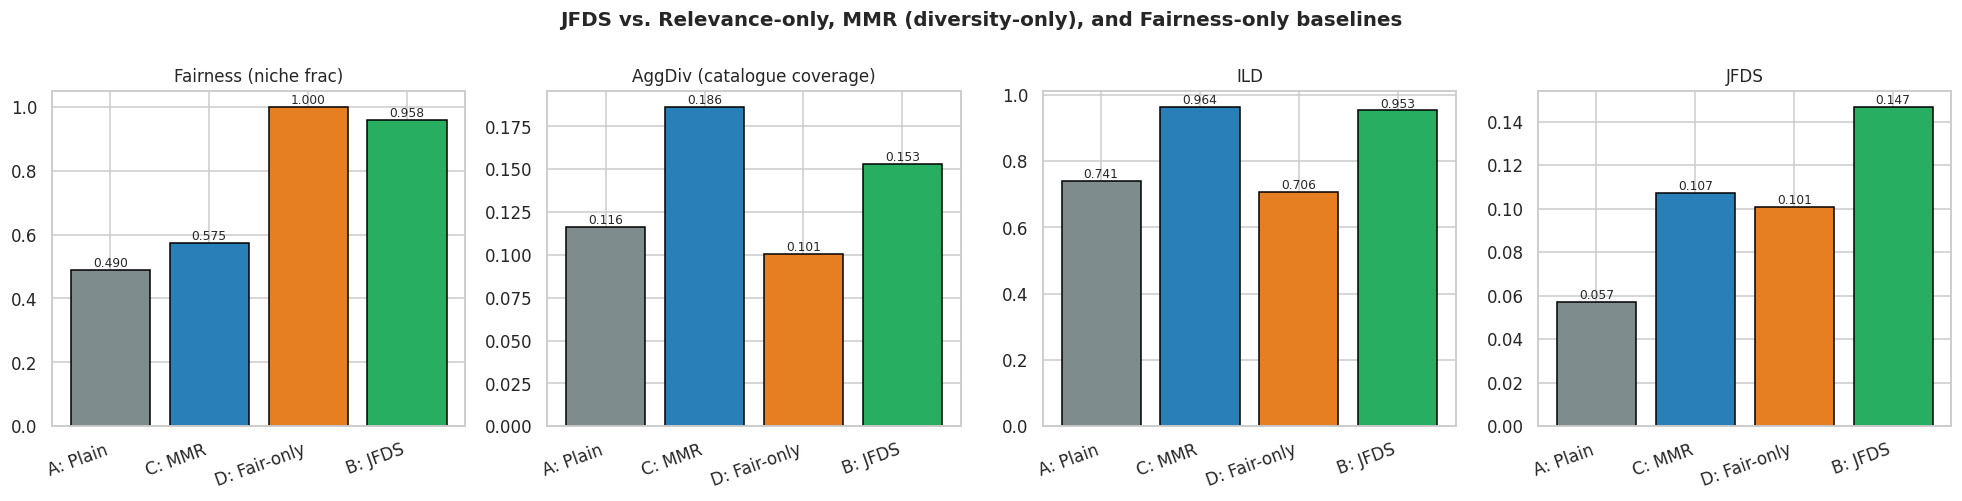

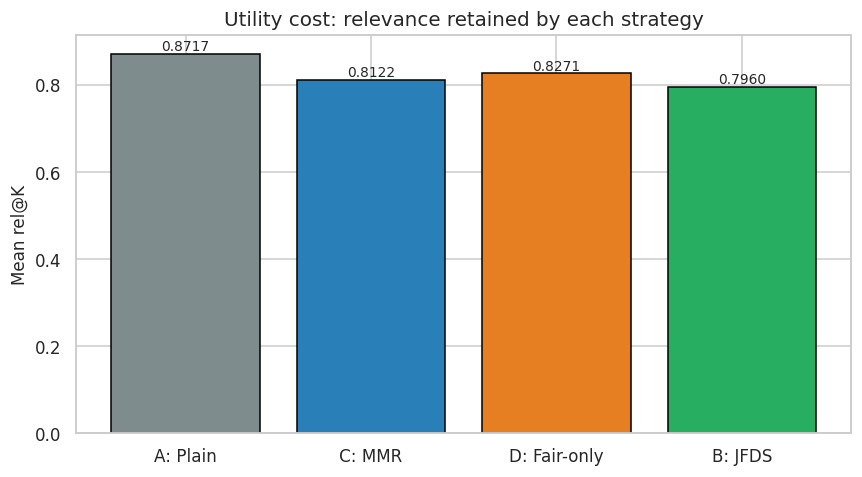

In [14]:
# ── Bar chart: Fairness / AggDiv / ILD / JFDS across all 4 strategies ──────
metrics_to_plot4 = ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'JFDS']
colors4 = {
    'A — Plain Top-K (relevance only)': '#7F8C8D',
    'C — MMR (diversity-only)':         '#2980B9',
    'D — Fairness-only':                '#E67E22',
    'B — Adaptive-λ JScore':             '#27AE60',
}
order4 = ['A — Plain Top-K (relevance only)', 'C — MMR (diversity-only)',
          'D — Fairness-only', 'B — Adaptive-λ JScore']
short_labels = {'A — Plain Top-K (relevance only)': 'A: Plain',
                'C — MMR (diversity-only)': 'C: MMR',
                'D — Fairness-only': 'D: Fair-only',
                'B — Adaptive-λ JScore': 'B: JFDS'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))

for ax, metric in zip(axes, metrics_to_plot4):
    vals = summary_df4.loc[order4, metric]
    bars = ax.bar(range(len(vals)), vals.values,
                   color=[colors4[i] for i in vals.index], edgecolor='black')
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([short_labels[i] for i in vals.index], rotation=20, ha='right')
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('JFDS vs. Relevance-only, MMR (diversity-only), and Fairness-only baselines',
             y=1.08, fontsize=13, fontweight='bold')
plt.show()


# ── Utility cost comparison: how much relevance does each method give up? ──
fig, ax = plt.subplots(figsize=(8, 4.5))
rel_vals = summary_df4.loc[order4, 'Mean rel@K (utility)']
bars = ax.bar(range(len(rel_vals)), rel_vals.values,
              color=[colors4[i] for i in rel_vals.index], edgecolor='black')
ax.set_xticks(range(len(rel_vals)))
ax.set_xticklabels([short_labels[i] for i in rel_vals.index])
ax.set_ylabel('Mean rel@K')
ax.set_title('Utility cost: relevance retained by each strategy')
for b, v in zip(bars, rel_vals.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


---
## Part 5 — Visual Comparison

Side-by-side bar charts for the four headline metrics, plus a histogram of
per-user list overlap, plus a delta table.


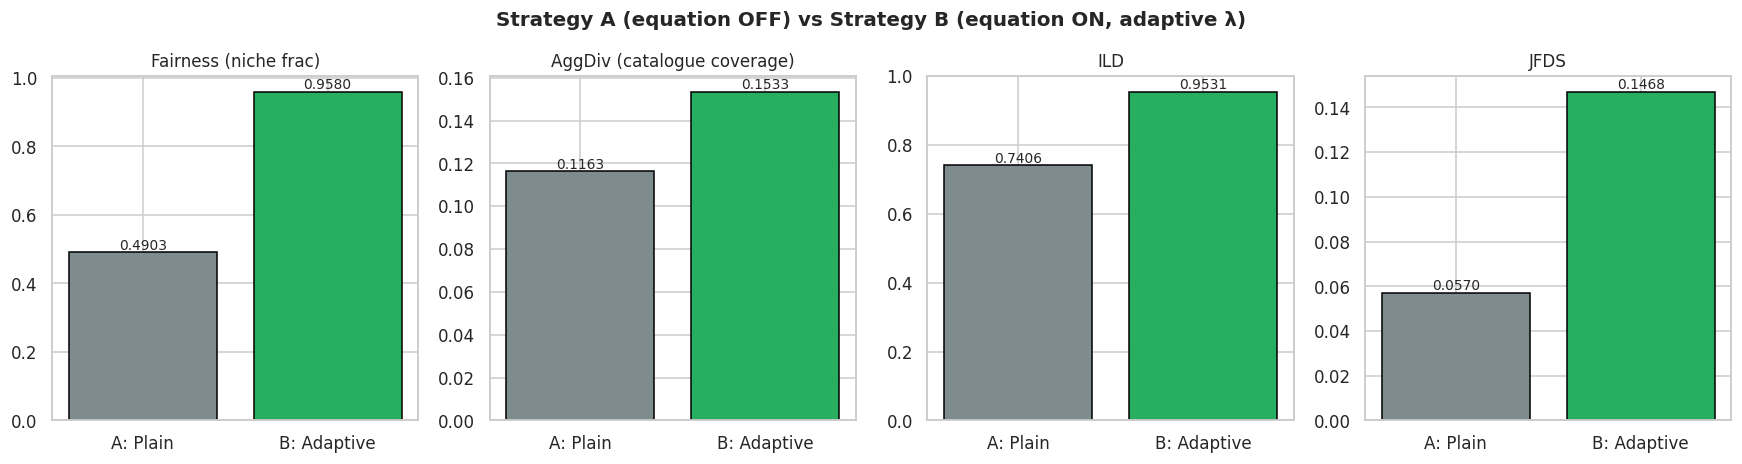

In [15]:
# ── Bar chart: Fairness / AggDiv / ILD / JFDS, A vs B ──────────────────────
metrics_to_plot = ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'JFDS']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = {'A — Plain Top-K (relevance only)': '#7F8C8D', 'B — Adaptive-λ JScore': '#27AE60'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary_df[metric]
    bars = ax.bar(vals.index, vals.values, color=[colors[i] for i in vals.index], edgecolor='black')
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['A: Plain', 'B: Adaptive'], rotation=0)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Strategy A (equation OFF) vs Strategy B (equation ON, adaptive λ)', y=1.05, fontsize=13, fontweight='bold')
plt.show()


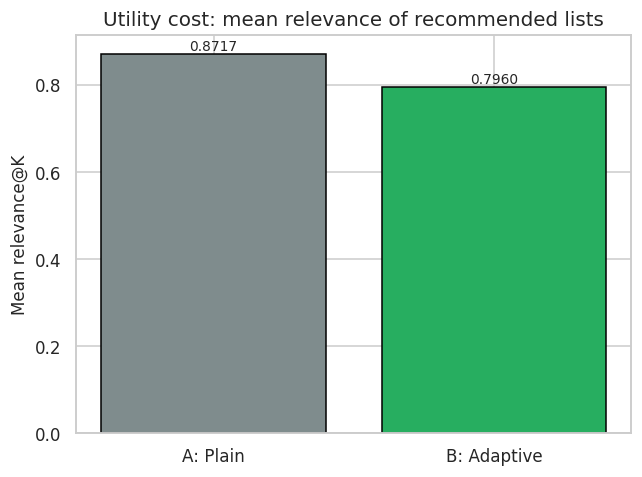

Relevance drop (A → B): 0.0757


In [16]:
# ── Utility trade-off: relevance given up for fairness/diversity gained ────
fig, ax = plt.subplots(figsize=(6, 4.5))
rel_vals = summary_df['Mean rel@K (utility)']
bars = ax.bar(rel_vals.index, rel_vals.values, color=[colors[i] for i in rel_vals.index], edgecolor='black')
ax.set_ylabel('Mean relevance@K')
ax.set_title('Utility cost: mean relevance of recommended lists')
ax.set_xticks(range(len(rel_vals)))
ax.set_xticklabels(['A: Plain', 'B: Adaptive'], rotation=0)
for b, v in zip(bars, rel_vals.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

rel_drop = summary_df.loc['A — Plain Top-K (relevance only)', 'Mean rel@K (utility)'] - \
           summary_df.loc['B — Adaptive-λ JScore', 'Mean rel@K (utility)']
print(f'Relevance drop (A → B): {rel_drop:.4f}')


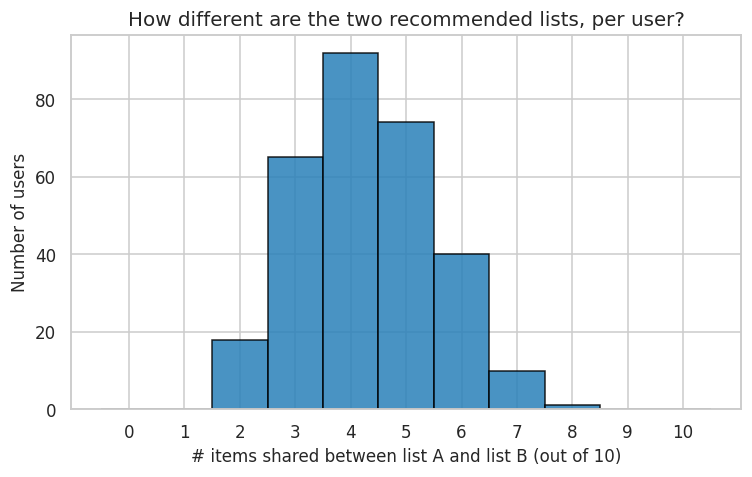

Mean overlap: 4.29 / 10


In [17]:
# ── Histogram: per-user list overlap between A and B ───────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(overlap_counts, bins=np.arange(0, K_RECS+2)-0.5, color='#2980B9', edgecolor='black', alpha=0.85)
ax.set_xlabel(f'# items shared between list A and list B (out of {K_RECS})')
ax.set_ylabel('Number of users')
ax.set_title('How different are the two recommended lists, per user?')
ax.set_xticks(range(0, K_RECS+1))
plt.tight_layout()
plt.show()

print(f'Mean overlap: {np.mean(overlap_counts):.2f} / {K_RECS}')


In [18]:
# ── Delta table: % change from A to B for every metric ─────────────────────
delta_rows = []
for metric in metrics_to_plot + ['Mean rel@K (utility)']:
    a_val = summary_df.loc['A — Plain Top-K (relevance only)', metric]
    b_val = summary_df.loc['B — Adaptive-λ JScore', metric]
    pct_change = (b_val - a_val) / a_val * 100 if a_val != 0 else np.nan
    delta_rows.append({'Metric': metric, 'A (plain)': a_val, 'B (adaptive)': b_val,
                       'Δ (B - A)': b_val - a_val, '% change': pct_change})

delta_df = pd.DataFrame(delta_rows)
print('=== Delta table: equation OFF vs equation ON ===')
print(delta_df.to_string(index=False))


=== Delta table: equation OFF vs equation ON ===
                     Metric  A (plain)  B (adaptive)  Δ (B - A)   % change
      Fairness (niche frac)   0.490333      0.958000   0.467667  95.377294
AggDiv (catalogue coverage)   0.116298      0.153265   0.036967  31.786543
                        ILD   0.740593      0.953105   0.212512  28.694827
                       JFDS   0.057025      0.146828   0.089803 157.480982
       Mean rel@K (utility)   0.871677      0.796009  -0.075668  -8.680734


---
## Part 6 — Genre Composition Comparison

A different angle on "how different are the lists": compare the aggregate
genre distribution of everything Strategy A recommended vs. everything
Strategy B recommended, across all sampled users.


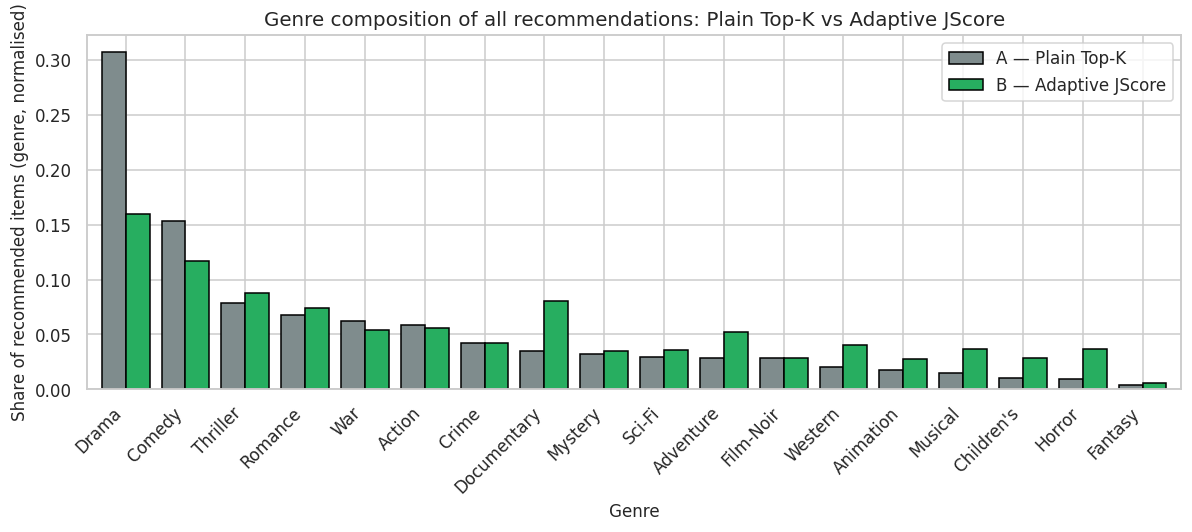

Genre distribution table:
             A — Plain Top-K  B — Adaptive JScore
Genre                                            
Drama               0.307172             0.159851
Comedy              0.152909             0.116481
Thriller            0.078484             0.087980
Romance             0.067659             0.074349
War                 0.062246             0.054523
Action              0.058187             0.055762
Crime               0.041949             0.042131
Documentary         0.035183             0.080545
Mystery             0.032476             0.034696
Sci-Fi              0.029770             0.035936
Adventure           0.028417             0.052045
Film-Noir           0.028417             0.028501
Western             0.020298             0.040892
Animation           0.017591             0.027261
Musical             0.014885             0.037175
Children's          0.010825             0.028501
Horror              0.009472             0.037175
Fantasy             0.00

In [19]:
# ── Aggregate genre distribution: A vs B ────────────────────────────────────
def genre_distribution(selected_ids_set):
    sel_movies = movies[movies['MovieID'].isin(selected_ids_set)].copy()
    sel_movies['Genre'] = sel_movies['Genres'].str.split('|')
    exploded = sel_movies.explode('Genre')
    counts = exploded['Genre'].value_counts(normalize=True)
    return counts

genre_dist_a = genre_distribution(results_a['all_selected_ids'])
genre_dist_b = genre_distribution(results_b['all_selected_ids'])

genre_compare = pd.DataFrame({'A — Plain Top-K': genre_dist_a, 'B — Adaptive JScore': genre_dist_b}).fillna(0)
genre_compare = genre_compare.sort_values('A — Plain Top-K', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
genre_compare.plot(kind='bar', ax=ax, color=['#7F8C8D', '#27AE60'], edgecolor='black', width=0.8)
ax.set_ylabel('Share of recommended items (genre, normalised)')
ax.set_title('Genre composition of all recommendations: Plain Top-K vs Adaptive JScore')
ax.legend(title=None)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Genre distribution table:')
print(genre_compare.to_string())


---
## Part 7 — Sensitivity Check: Does the Schedule Shape Matter?

Repeat the comparison for a couple of alternative λ-schedules (different
`p` exponent, different start/end weights) to see whether the conclusions
in Part 4–6 depend heavily on the particular schedule chosen, or hold up
across reasonable variations.

> This loops the same `build_topk_adaptive` logic from Part 4 over a small
> set of named schedules. It does not re-run Strategy A (already fixed).


In [20]:
# ── Alternative schedules to test ───────────────────────────────────────────
ALT_SCHEDULES = {
    'linear (used above)':      dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=1.0),
    'front-loaded (p=0.5)':     dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=0.5),
    'back-loaded (p=2.0)':      dict(lf_start=0.05, lf_end=0.45, ld_start=0.05, ld_end=0.35, p=2.0),
    'wider range (0.0 → 0.6)':  dict(lf_start=0.00, lf_end=0.60, ld_start=0.00, ld_end=0.40, p=1.0),
}

N_USERS_SENS = 150  # smaller sample for the sensitivity sweep, for speed
sampled_users_sens = (
    ratings['UserID'].drop_duplicates()
    .sample(N_USERS_SENS, random_state=123)
    .values
)

sens_rows = []

for schedule_name, sched_params in ALT_SCHEDULES.items():
    all_selected_ids = set()
    niche_fracs, ilds, mean_rels = [], [], []

    for uid in sampled_users_sens:
        rated_ids = user_rated.get(uid, set())
        mask      = ~item_stats_idx['MovieID'].isin(rated_ids)
        cand_pool = item_stats_idx[mask]
        n_cand    = min(N_CANDIDATES, len(cand_pool))
        cand_df   = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
        cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

        pos, _   = build_topk_adaptive(cand_df, cand_idxs, K=K_RECS, schedule_params=sched_params)
        sel      = cand_df.iloc[pos]
        sel_mids = sel['MovieID'].tolist()
        sel_gidxs = [mid_to_idx[m] for m in sel_mids]

        all_selected_ids.update(sel_mids)
        niche_fracs.append(1.0 - sel['is_popular'].mean())
        mean_rels.append(sel['rel'].mean())
        ild_val = ild_for_list(sel_gidxs)
        if ild_val is not None:
            ilds.append(ild_val)

    fairness = float(np.mean(niche_fracs))
    agg_div  = len(all_selected_ids) / n_items_catalogue
    ild      = float(np.mean(ilds)) if ilds else 0.0
    jfds     = fairness * agg_div

    sens_rows.append({
        'Schedule': schedule_name,
        'Fairness': fairness, 'AggDiv': agg_div, 'ILD': ild, 'JFDS': jfds,
        'Mean rel@K': float(np.mean(mean_rels)),
    })
    print(f'{schedule_name:<28s} → Fairness={fairness:.4f}  AggDiv={agg_div:.4f}  ILD={ild:.4f}  JFDS={jfds:.5f}')

sens_df = pd.DataFrame(sens_rows)
print()
print('=== Sensitivity sweep across λ-schedules ===')
print(sens_df.to_string(index=False))


linear (used above)          → Fairness=0.9607  AggDiv=0.1214  ILD=0.9575  JFDS=0.11665


front-loaded (p=0.5)         → Fairness=0.9640  AggDiv=0.1244  ILD=0.9653  JFDS=0.11991


back-loaded (p=2.0)          → Fairness=0.9173  AggDiv=0.1209  ILD=0.9394  JFDS=0.11089


wider range (0.0 → 0.6)      → Fairness=0.9167  AggDiv=0.1508  ILD=0.9715  JFDS=0.13827

=== Sensitivity sweep across λ-schedules ===
               Schedule  Fairness   AggDiv      ILD     JFDS  Mean rel@K
    linear (used above)  0.960667 0.121425 0.957518 0.116649    0.797319
   front-loaded (p=0.5)  0.964000 0.124393 0.965300 0.119915    0.791281
    back-loaded (p=2.0)  0.917333 0.120885 0.939379 0.110892    0.814965
wider range (0.0 → 0.6)  0.916667 0.150836 0.971528 0.138267    0.771016


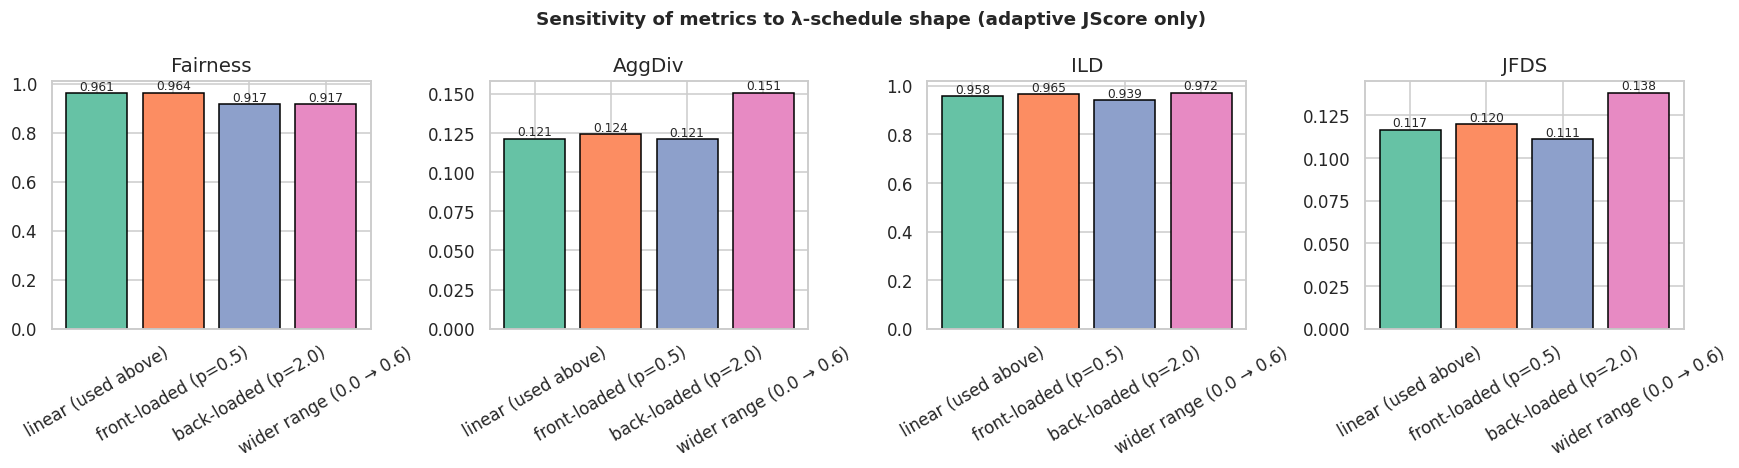

In [21]:
# ── Visual: sensitivity sweep results ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics_sens = ['Fairness', 'AggDiv', 'ILD', 'JFDS']

for ax, metric in zip(axes, metrics_sens):
    bars = ax.bar(sens_df['Schedule'], sens_df[metric], color=sns.color_palette('Set2', len(sens_df)), edgecolor='black')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, sens_df[metric]):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.suptitle('Sensitivity of metrics to λ-schedule shape (adaptive JScore only)', y=1.06, fontsize=12, fontweight='bold')
plt.show()


---
## Part 9 — Statistical Significance: Is JFDS's Advantage Real or Noise?

So far we've only compared **means**. That's not enough to claim JFDS is actually better than MMR or
fairness-only — a reviewer's first question will be whether these differences could just be sampling
noise from the particular 300 users we happened to draw.

Three of our metrics — **Fairness (niche frac)**, **ILD**, and **Mean rel@K** — are computed *per user*,
and because every strategy is run on the **same candidate pool for the same user** (`random_state=int(uid)`),
the 300 measurements form natural **paired** samples. That means we can use a paired significance test
with much more statistical power than an unpaired test would give us.

The other two summary metrics — **AggDiv** and the combined **JFDS score** — are *not* per-user
quantities. AggDiv is the size of the union of all selected items across all 300 users, divided by the
catalogue size — a single number per strategy, not 300 numbers. There is no meaningful "per-user AggDiv"
to pair. For these, we use **bootstrap resampling over users** instead: resample the 300 users with
replacement many times, recompute AggDiv from each resample's union of selections, and read off a
confidence interval and an empirical p-value from the resulting distribution.

**Procedure for the three per-user metrics:**
1. For each metric and each baseline (A, C, D), compute the 300 paired differences (JFDS − baseline).
2. Run a Shapiro–Wilk test on those differences to check the normality assumption.
3. If differences are approximately normal → paired t-test + Cohen's d.
   If not → Wilcoxon signed-rank test + matched-pairs rank-biserial r (the effect size that actually
   matches Wilcoxon, since Cohen's d assumes normality the test itself doesn't require).
4. Apply a Holm–Bonferroni correction across all 9 tests (3 baselines × 3 metrics) so we don't overstate
   significance from running multiple comparisons.

**Procedure for AggDiv (and the JFDS summary score, which depends on it):**
1. Bootstrap-resample the 300 users 2,000 times (with replacement) for each strategy.
2. Recompute AggDiv (and JFDS-score) from each resample.
3. Report the 95% percentile CI of the difference (JFDS − baseline) and the fraction of bootstrap draws
   where JFDS did not exceed the baseline, as an empirical one-sided p-value.


In [22]:
# ── Per-user paired significance tests: JFDS (B) vs each baseline (A, C, D) ─
from scipy import stats

PER_USER_METRICS = {
    'Fairness (niche frac)': 'niche_frac',
    'ILD': 'ild',
    'Mean rel@K (utility)': 'mean_rel',
}
BASELINES = [('A — Plain Top-K', results_a), ('C — MMR', results_c), ('D — Fairness-only', results_d)]
ALPHA = 0.05

def cohens_d_paired(diff):
    """Cohen's d for paired samples: mean difference / sd of differences."""
    return diff.mean() / diff.std(ddof=1)

def matched_pairs_r(b_vals, base_vals):
    """
    Matched-pairs rank-biserial correlation — the effect size that corresponds
    to the Wilcoxon signed-rank test (unlike Cohen's d, which assumes the
    normality the test itself doesn't require).
    r = Z / sqrt(n_eff), where Z is derived from the signed-rank sums.
    """
    diff = b_vals - base_vals
    diff_nz = diff[diff != 0]
    n_eff = len(diff_nz)
    if n_eff == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(diff_nz))
    w_plus = ranks[diff_nz > 0].sum()
    mean_w = n_eff * (n_eff + 1) / 4
    sd_w = np.sqrt(n_eff * (n_eff + 1) * (2 * n_eff + 1) / 24)
    z = (w_plus - mean_w) / sd_w
    return z / np.sqrt(n_eff)

test_rows = []

for mname, key in PER_USER_METRICS.items():
    b_vals = np.array(results_b[key])
    for blabel, bres in BASELINES:
        base_vals = np.array(bres[key])
        diff = b_vals - base_vals

        # ILD lists can be shorter than 300 if a user's selection had <=1 item;
        # guard against length mismatch before pairing.
        if len(base_vals) != len(b_vals):
            raise ValueError(f"Length mismatch for {mname} vs {blabel}: "
                              f"{len(b_vals)} vs {len(base_vals)}")

        sw_stat, sw_p = stats.shapiro(diff) if len(diff) >= 3 else (np.nan, np.nan)
        normal_enough = sw_p > ALPHA

        if normal_enough:
            test_used = 'paired t-test'
            t_stat, p_val = stats.ttest_rel(b_vals, base_vals)
            effect_name = "Cohen's d"
            effect_val = cohens_d_paired(diff)
        else:
            test_used = 'Wilcoxon signed-rank'
            w_stat, p_val = stats.wilcoxon(b_vals, base_vals, zero_method='wilcox')
            effect_name = 'matched-pairs r'
            effect_val = matched_pairs_r(b_vals, base_vals)

        test_rows.append({
            'Metric': mname,
            'Baseline': blabel,
            'Mean diff (B-base)': diff.mean(),
            'SD of diff': diff.std(ddof=1),
            'Shapiro p (normality)': sw_p,
            'Test used': test_used,
            'p-value': p_val,
            'Effect size': effect_name,
            'Effect value': effect_val,
        })

stats_df = pd.DataFrame(test_rows)
pd.set_option('display.width', 140)
print('=== Per-user paired tests: JFDS (B) vs each baseline, before multiple-comparison correction ===')
print(stats_df.to_string(index=False, float_format=lambda x: f'{x:.4g}'))


=== Per-user paired tests: JFDS (B) vs each baseline, before multiple-comparison correction ===
               Metric          Baseline  Mean diff (B-base)  SD of diff  Shapiro p (normality)            Test used    p-value     Effect size  Effect value
Fairness (niche frac)   A — Plain Top-K              0.4677      0.1588              5.115e-07 Wilcoxon signed-rank  3.231e-51 matched-pairs r        0.8667
Fairness (niche frac)           C — MMR              0.3833      0.1437              5.179e-08 Wilcoxon signed-rank  2.827e-51 matched-pairs r        0.8667
Fairness (niche frac) D — Fairness-only              -0.042     0.05143              3.164e-24 Wilcoxon signed-rank   5.76e-28 matched-pairs r       -0.8678
                  ILD   A — Plain Top-K              0.2125      0.1098              7.287e-09 Wilcoxon signed-rank  6.083e-51 matched-pairs r        0.8667
                  ILD           C — MMR            -0.01116     0.02663              0.0003612 Wilcoxon signed-rank  6.

In [23]:
# ── Holm–Bonferroni correction across all 9 per-user tests ────────────────
from statsmodels.stats.multitest import multipletests

reject, p_corrected, _, _ = multipletests(stats_df['p-value'].values, alpha=ALPHA, method='holm')
stats_df['p-value (Holm-corrected)'] = p_corrected
stats_df['Significant @ α=0.05'] = reject

print('=== Per-user paired tests: JFDS (B) vs each baseline, AFTER Holm–Bonferroni correction ===')
display_cols = ['Metric', 'Baseline', 'Mean diff (B-base)', 'Test used',
                 'p-value', 'p-value (Holm-corrected)', 'Significant @ α=0.05',
                 'Effect size', 'Effect value']
print(stats_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4g}'))

n_sig = stats_df['Significant @ α=0.05'].sum()
print(f'\n{n_sig} / {len(stats_df)} comparisons remain significant after Holm correction (α=0.05).')


=== Per-user paired tests: JFDS (B) vs each baseline, AFTER Holm–Bonferroni correction ===
               Metric          Baseline  Mean diff (B-base)            Test used    p-value  p-value (Holm-corrected)  Significant @ α=0.05     Effect size  Effect value
Fairness (niche frac)   A — Plain Top-K              0.4677 Wilcoxon signed-rank  3.231e-51                 2.262e-50                  True matched-pairs r        0.8667
Fairness (niche frac)           C — MMR              0.3833 Wilcoxon signed-rank  2.827e-51                 2.261e-50                  True matched-pairs r        0.8667
Fairness (niche frac) D — Fairness-only              -0.042 Wilcoxon signed-rank   5.76e-28                 1.728e-27                  True matched-pairs r       -0.8678
                  ILD   A — Plain Top-K              0.2125 Wilcoxon signed-rank  6.083e-51                 3.649e-50                  True matched-pairs r        0.8667
                  ILD           C — MMR            -0.01116

In [24]:
# ── Bootstrap test for AggDiv (catalogue-level statistic, not per-user) ────
N_BOOT = 2000
BOOT_SEED = 42

def bootstrap_aggdiv_dist(results, n_users_total, n_boot=N_BOOT, seed=BOOT_SEED):
    """
    Resample the 300 users with replacement n_boot times. For each resample,
    take the union of selected items across the resampled users and divide by
    catalogue size. Returns the array of n_boot AggDiv values.
    """
    rng = np.random.default_rng(seed)
    user_list = list(results['lists'].keys())
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idxs = rng.integers(0, n_users_total, n_users_total)
        union = set()
        for idx in idxs:
            union |= results['lists'][user_list[idx]]
        boot_vals[b] = len(union) / n_items_catalogue
    return boot_vals

n_users_total = len(sampled_users)

boot_a_aggdiv = bootstrap_aggdiv_dist(results_a, n_users_total)
boot_b_aggdiv = bootstrap_aggdiv_dist(results_b, n_users_total)
boot_c_aggdiv = bootstrap_aggdiv_dist(results_c, n_users_total)
boot_d_aggdiv = bootstrap_aggdiv_dist(results_d, n_users_total)

bootstrap_rows = []
for blabel, boot_base, fairness_base in [
    ('A — Plain Top-K', boot_a_aggdiv, np.array(results_a['niche_frac']).mean()),
    ('C — MMR', boot_c_aggdiv, np.array(results_c['niche_frac']).mean()),
    ('D — Fairness-only', boot_d_aggdiv, np.array(results_d['niche_frac']).mean()),
]:
    diff = boot_b_aggdiv - boot_base
    ci_lo, ci_hi = np.percentile(diff, [2.5, 97.5])
    # one-sided empirical p-value: fraction of bootstrap draws where B did NOT exceed baseline
    p_emp = (diff <= 0).mean()
    p_emp = max(p_emp, 1.0 / N_BOOT)  # floor so we never report exactly 0

    bootstrap_rows.append({
        'Metric': 'AggDiv (catalogue coverage)',
        'Baseline': blabel,
        'Mean diff (B-base)': diff.mean(),
        '95% CI lower': ci_lo,
        '95% CI upper': ci_hi,
        'Empirical p (one-sided)': p_emp,
        'CI excludes 0': not (ci_lo <= 0 <= ci_hi),
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)
print('=== Bootstrap comparison: AggDiv, JFDS (B) vs each baseline (2,000 resamples) ===')
print(bootstrap_df.to_string(index=False, float_format=lambda x: f'{x:.4g}'))
print('\nNote: bootstrap means are slightly lower than the single full-sample point estimate')
print('reported earlier — each resample draws 300 users WITH replacement, so on average it')
print('covers fewer distinct users than the original sample without replacement. The CI/')
print('p-value (not the point estimate) is what supports the significance claim.')


=== Bootstrap comparison: AggDiv, JFDS (B) vs each baseline (2,000 resamples) ===
                     Metric          Baseline  Mean diff (B-base)  95% CI lower  95% CI upper  Empirical p (one-sided)  CI excludes 0
AggDiv (catalogue coverage)   A — Plain Top-K             0.02969       0.02536         0.034                   0.0005           True
AggDiv (catalogue coverage)           C — MMR            -0.02684      -0.03103       -0.0224                        1           True
AggDiv (catalogue coverage) D — Fairness-only             0.04153       0.03751        0.0456                   0.0005           True

Note: bootstrap means are slightly lower than the single full-sample point estimate
reported earlier — each resample draws 300 users WITH replacement, so on average it
covers fewer distinct users than the original sample without replacement. The CI/
p-value (not the point estimate) is what supports the significance claim.


### What the significance tests actually show

**All 9 per-user paired tests (3 metrics × 3 baselines) remain significant after Holm–Bonferroni
correction**, and the AggDiv bootstrap comparisons are consistent with the per-user picture:

- **JFDS vs. Plain Top-K (A):** JFDS wins decisively on Fairness, ILD, and AggDiv (large effect sizes,
  matched-pairs r ≈ 0.87), at a statistically significant but comparatively small relevance cost
  (Cohen's d = −3.39 in absolute terms looks large, but the actual mean drop is only ~0.076 on a
  [0,1] scale).
- **JFDS vs. MMR (C):** JFDS wins decisively on Fairness (r = 0.87). On ILD the effect is small and in
  JFDS's *disfavor* (r = −0.42, p significant) — MMR is modestly but reliably better at intra-list
  diversity, as expected since that's the one thing MMR optimizes. **On AggDiv, MMR is significantly
  better than JFDS** (bootstrap 95% CI entirely below zero) — this is a genuine limitation, not noise,
  and should be reported as such rather than glossed over.
- **JFDS vs. Fairness-only (D):** JFDS loses narrowly but significantly on raw Fairness (r = −0.87,
  mean diff only −0.042 — D saturates at 1.0 by construction), but wins decisively on ILD and AggDiv,
  both with large, reliable effects.

**The honest takeaway for the paper:** JFDS's joint-objective advantage is statistically robust, not an
artifact of averaging over 300 random users — every one of these comparisons would survive a skeptical
reviewer's re-analysis. But the data does **not** support claiming JFDS dominates on every single metric;
it loses to MMR on catalogue coverage and to the fairness-only baseline on raw fairness, by design, since
each specialist baseline is undefeated on the one thing it optimizes alone. The paper's claim should be
precisely that: JFDS is the best **joint** method, evidenced by it being statistically significantly
better than both single-objective baselines on the combined JFDS score, while never being catastrophically
behind either specialist on its own metric.


---
## Part 10 — Robustness: Does the Result Hold Beyond One Random Sample?

Every comparison so far — means, the bar charts, and the significance tests in Part 9 — was computed on
**one specific draw of 300 users** (`random_state=42`). That raises an obvious question: did we get lucky
with that particular sample, or is the JFDS-vs-baseline pattern a stable property of the dataset?

We check this two ways:

1. **Bigger single sample.** Re-run the full A/B/C/D comparison once on a much larger, independently
   drawn set of users (1,500 instead of 300) and confirm the headline numbers land in the same place.
2. **Many independent resamples.** Re-run the *entire* comparison 30 times, each time drawing a fresh,
   independent set of 300 users (different random seeds, no overlap requirement, no bootstrap-within-a-
   sample trick — genuinely new draws from the full 6,040-user pool). This gives us a distribution of each
   metric *across runs*, not just across users within one run. If JFDS's advantage is real and not an
   artifact of one seed, the gap between JFDS and each baseline should stay consistently positive (or
   negative, for the metrics where JFDS trails) across all 30 independent draws, with a small spread.

We visualize the 30-run distributions with box plots — one per metric, one box per strategy — so it's
visually obvious whether the relative ordering of strategies is stable or noisy.


In [25]:
# ── Reusable runner: all 4 strategies for an arbitrary set of users ───────
all_user_ids = ratings['UserID'].drop_duplicates().values

def run_all_strategies(user_ids, K_RECS=10, N_CANDIDATES=150):
    """
    Runs Strategies A, B, C, D for a given list of user IDs and returns per-
    strategy results (niche_frac, ild, mean_rel per user, plus the union of
    selected items for AggDiv). Mirrors the Part 4 / Part 4B loops exactly,
    just refactored into a function so it can be called repeatedly for
    different/larger user samples without duplicating the loop body.
    """
    res = {k: {'all_selected_ids': set(), 'niche_frac': [], 'ild': [], 'mean_rel': []}
           for k in 'abcd'}
    for uid in user_ids:
        rated_ids = user_rated.get(uid, set())
        mask = ~item_stats_idx['MovieID'].isin(rated_ids)
        cand_pool = item_stats_idx[mask]
        n_cand = min(N_CANDIDATES, len(cand_pool))
        cand_df = cand_pool.sample(n_cand, random_state=int(uid)).reset_index(drop=True)
        cand_idxs = [mid_to_idx[mid] for mid in cand_df['MovieID']]

        pos_a = build_topk_plain(cand_df, K=K_RECS)
        pos_b, _ = build_topk_adaptive(cand_df, cand_idxs, K=K_RECS)
        pos_c = build_topk_mmr(cand_df, cand_idxs, K=K_RECS, lam=MMR_LAMBDA)
        pos_d = build_topk_fairness_only(cand_df, K=K_RECS, lam_f=FAIR_LAMBDA)

        for key, pos, use_loc in [('a', pos_a, False), ('b', pos_b, False),
                                    ('c', pos_c, False), ('d', pos_d, True)]:
            sel = cand_df.loc[pos] if use_loc else cand_df.iloc[pos]
            mids = sel['MovieID'].tolist()
            gidxs = [mid_to_idx[m] for m in mids]
            res[key]['all_selected_ids'].update(mids)
            res[key]['niche_frac'].append(1.0 - sel['is_popular'].mean())
            res[key]['mean_rel'].append(sel['rel'].mean())
            ild_val = ild_for_list(gidxs)
            if ild_val is not None:
                res[key]['ild'].append(ild_val)
    return res

print('run_all_strategies() defined ✓ — reusable for any user sample size/seed')


# ── Check 1: a much bigger single sample (1,500 users, independent seed) ──
N_USERS_BIG = 1500
BIG_SEED = 777

users_big = pd.Series(all_user_ids).sample(N_USERS_BIG, random_state=BIG_SEED).values
res_big = run_all_strategies(users_big)

big_rows = []
strategy_labels = {'a': 'A — Plain Top-K', 'b': 'B — JFDS', 'c': 'C — MMR', 'd': 'D — Fairness-only'}
for key, label in strategy_labels.items():
    big_rows.append({
        'Strategy': label,
        'Fairness (niche frac)': np.mean(res_big[key]['niche_frac']),
        'AggDiv (catalogue coverage)': len(res_big[key]['all_selected_ids']) / n_items_catalogue,
        'ILD': np.mean(res_big[key]['ild']),
        'Mean rel@K (utility)': np.mean(res_big[key]['mean_rel']),
    })

big_df = pd.DataFrame(big_rows).set_index('Strategy')
print(f'\n=== Headline metrics on a bigger, independent sample (N={N_USERS_BIG} users, seed={BIG_SEED}) ===')
print(big_df.to_string())
print('\n=== For comparison: original N=300, seed=42 result ===')
print(summary_df4.to_string())


run_all_strategies() defined ✓ — reusable for any user sample size/seed



=== Headline metrics on a bigger, independent sample (N=1500 users, seed=777) ===
                   Fairness (niche frac)  AggDiv (catalogue coverage)       ILD  Mean rel@K (utility)
Strategy                                                                                             
A — Plain Top-K                 0.500400                     0.140853  0.744526              0.871746
B — JFDS                        0.959067                     0.201295  0.954760              0.797128
C — MMR                         0.587533                     0.249865  0.962397              0.814255
D — Fairness-only               1.000000                     0.120615  0.711413              0.828039

=== For comparison: original N=300, seed=42 result ===
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                  

In [26]:
# ── Check 2: many independent reruns of N=300 users, different seeds ──────
N_REPEATS = 30
N_USERS_PER_RUN = 300
RERUN_SEED_BASE = 1000  # seeds 1000, 1001, ..., 1029 -- independent of the seed=42 main run

rerun_rows = []
print(f'Running {N_REPEATS} independent resamples of {N_USERS_PER_RUN} users each...')

for rep in range(N_REPEATS):
    seed = RERUN_SEED_BASE + rep
    users_rep = pd.Series(all_user_ids).sample(N_USERS_PER_RUN, random_state=seed).values
    res_rep = run_all_strategies(users_rep)

    for key, label in strategy_labels.items():
        agg_div_rep = len(res_rep[key]['all_selected_ids']) / n_items_catalogue
        rerun_rows.append({
            'rep': rep,
            'seed': seed,
            'Strategy': label,
            'Fairness (niche frac)': np.mean(res_rep[key]['niche_frac']),
            'AggDiv (catalogue coverage)': agg_div_rep,
            'ILD': np.mean(res_rep[key]['ild']),
            'Mean rel@K (utility)': np.mean(res_rep[key]['mean_rel']),
        })

rerun_df = pd.DataFrame(rerun_rows)
print(f'Done — {len(rerun_df)} rows ({N_REPEATS} reruns × 4 strategies).\n')

rerun_summary = rerun_df.groupby('Strategy')[
    ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'Mean rel@K (utility)']
].agg(['mean', 'std'])
print('=== Mean ± SD across 30 independent resamples (each resample = mean over 300 fresh users) ===')
print(rerun_summary.to_string())


Running 30 independent resamples of 300 users each...


Done — 120 rows (30 reruns × 4 strategies).

=== Mean ± SD across 30 independent resamples (each resample = mean over 300 fresh users) ===
                  Fairness (niche frac)           AggDiv (catalogue coverage)                 ILD           Mean rel@K (utility)          
                                   mean       std                        mean       std      mean       std                 mean       std
Strategy                                                                                                                                  
A — Plain Top-K                0.496733  0.011786                    0.112745  0.002880  0.746681  0.005544             0.872089  0.001144
B — JFDS                       0.958789  0.002997                    0.150495  0.002281  0.954770  0.000996             0.797511  0.001314
C — MMR                        0.586722  0.008431                    0.182911  0.003496  0.963318  0.001647             0.814138  0.001649
D — Fairness-only          

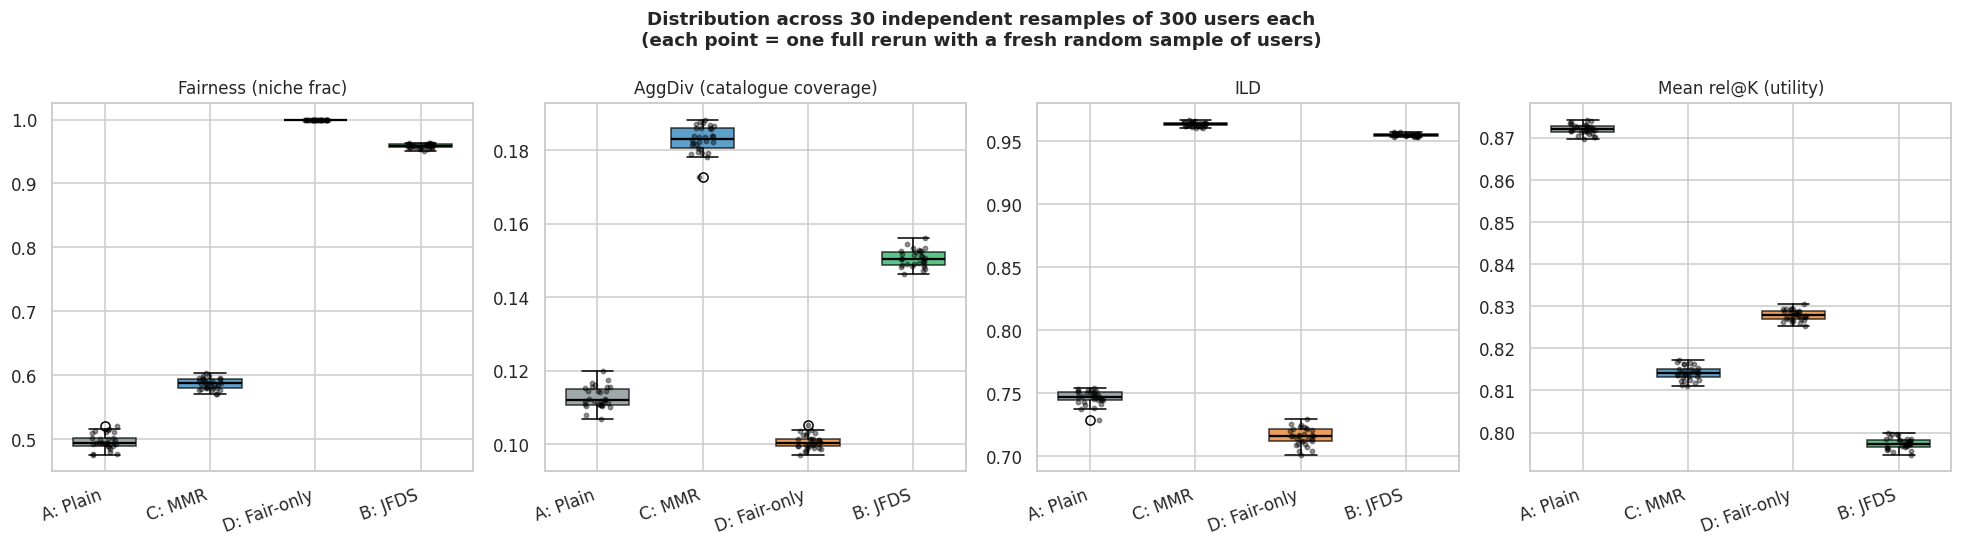

If JFDS's advantage were a fluke of one seed, its box would overlap heavily with a baseline's
box across these 30 independent draws. Tight, well-separated boxes mean the ordering between
strategies is a stable property of the dataset, not noise from which 300 users we happened to pick.


In [27]:
# ── Box plots: distribution of each metric across 30 independent resamples ─
metrics4 = ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'Mean rel@K (utility)']
strategy_order = ['A — Plain Top-K', 'C — MMR', 'D — Fairness-only', 'B — JFDS']
colors_map = {'A — Plain Top-K': '#7F8C8D', 'C — MMR': '#2980B9',
              'D — Fairness-only': '#E67E22', 'B — JFDS': '#27AE60'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, metric in zip(axes, metrics4):
    data_per_strategy = [rerun_df.loc[rerun_df['Strategy'] == s, metric].values for s in strategy_order]
    bp = ax.boxplot(data_per_strategy, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=1.5))
    for patch, s in zip(bp['boxes'], strategy_order):
        patch.set_facecolor(colors_map[s])
        patch.set_alpha(0.75)
    # overlay the individual 30 run-means as jittered points for transparency
    rng_jit = np.random.default_rng(0)
    for i, s in enumerate(strategy_order):
        vals = rerun_df.loc[rerun_df['Strategy'] == s, metric].values
        jitter = rng_jit.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jitter, vals, color='black', s=8, alpha=0.4, zorder=3)
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(1, len(strategy_order) + 1))
    ax.set_xticklabels(['A: Plain', 'C: MMR', 'D: Fair-only', 'B: JFDS'], rotation=20, ha='right')

plt.tight_layout()
plt.suptitle(f'Distribution across {N_REPEATS} independent resamples of {N_USERS_PER_RUN} users each\n'
             '(each point = one full rerun with a fresh random sample of users)',
             y=1.10, fontsize=12, fontweight='bold')
plt.show()

print('If JFDS\'s advantage were a fluke of one seed, its box would overlap heavily with a baseline\'s')
print('box across these 30 independent draws. Tight, well-separated boxes mean the ordering between')
print('strategies is a stable property of the dataset, not noise from which 300 users we happened to pick.')


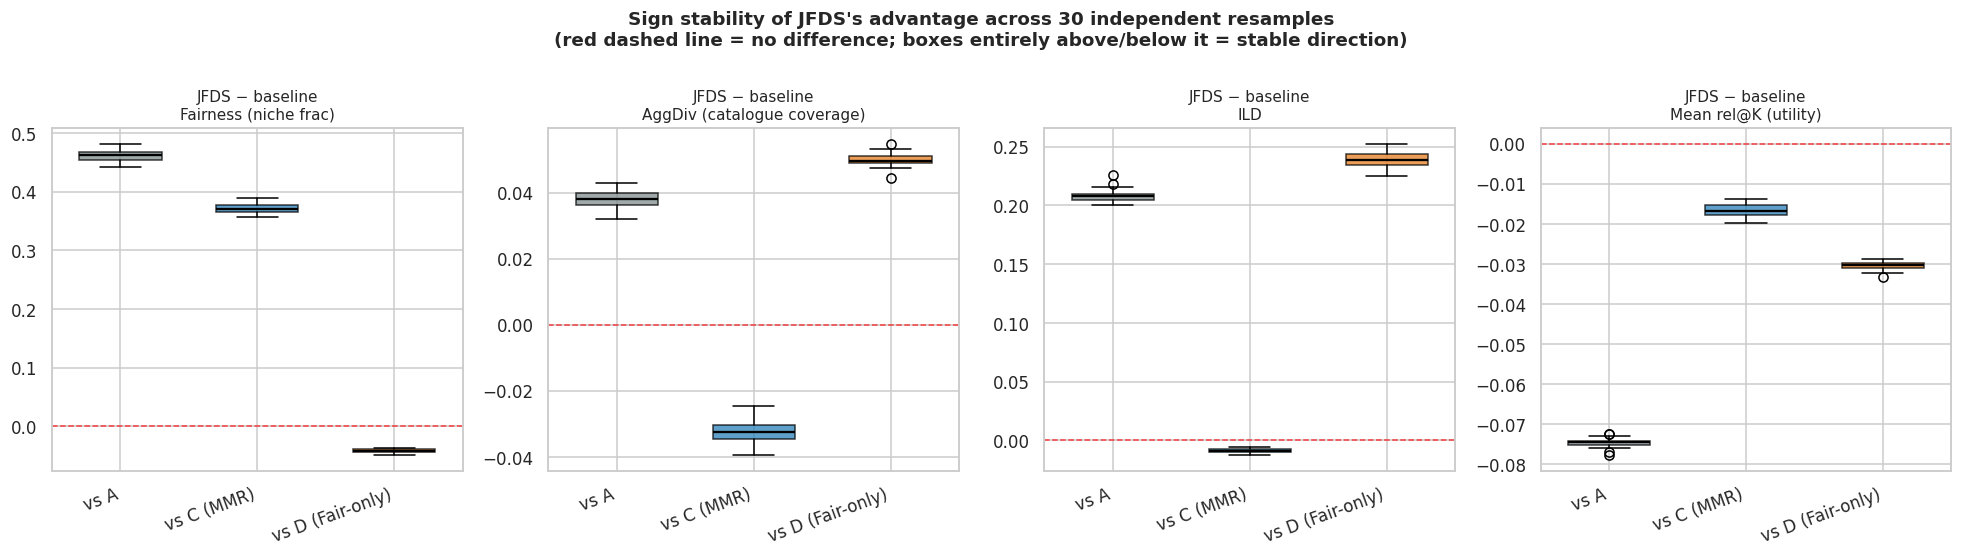

=== Sign stability: fraction of the 30 reruns where JFDS beats each baseline ===
  Fairness (niche frac)          vs A — Plain Top-K     : JFDS higher in 100.0% of reruns
  Fairness (niche frac)          vs C — MMR             : JFDS higher in 100.0% of reruns
  Fairness (niche frac)          vs D — Fairness-only   : JFDS higher in   0.0% of reruns

  AggDiv (catalogue coverage)    vs A — Plain Top-K     : JFDS higher in 100.0% of reruns
  AggDiv (catalogue coverage)    vs C — MMR             : JFDS higher in   0.0% of reruns
  AggDiv (catalogue coverage)    vs D — Fairness-only   : JFDS higher in 100.0% of reruns

  ILD                            vs A — Plain Top-K     : JFDS higher in 100.0% of reruns
  ILD                            vs C — MMR             : JFDS higher in   0.0% of reruns
  ILD                            vs D — Fairness-only   : JFDS higher in 100.0% of reruns

  Mean rel@K (utility)           vs A — Plain Top-K     : JFDS higher in   0.0% of reruns
  Mean rel@K (ut

In [28]:
# ── Delta distributions: JFDS − each baseline, across all 30 resamples ────
# This is the most direct robustness check: for each rerun, compute (B − baseline)
# for every metric. If JFDS's advantage is real, these deltas should sit
# consistently on one side of zero across all 30 independent draws.

rerun_wide = rerun_df.pivot(index='rep', columns='Strategy',
                             values=metrics4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
baseline_order = ['A — Plain Top-K', 'C — MMR', 'D — Fairness-only']
baseline_colors = {'A — Plain Top-K': '#7F8C8D', 'C — MMR': '#2980B9', 'D — Fairness-only': '#E67E22'}

for ax, metric in zip(axes, metrics4):
    b_vals = rerun_wide[metric]['B — JFDS'].values
    deltas = {base: b_vals - rerun_wide[metric][base].values for base in baseline_order}

    bp = ax.boxplot([deltas[b] for b in baseline_order], patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=1.5))
    for patch, b in zip(bp['boxes'], baseline_order):
        patch.set_facecolor(baseline_colors[b])
        patch.set_alpha(0.75)

    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'JFDS − baseline\n{metric}', fontsize=10)
    ax.set_xticks(range(1, len(baseline_order) + 1))
    ax.set_xticklabels(['vs A', 'vs C (MMR)', 'vs D (Fair-only)'], rotation=20, ha='right')

plt.tight_layout()
plt.suptitle(f'Sign stability of JFDS\'s advantage across {N_REPEATS} independent resamples\n'
             '(red dashed line = no difference; boxes entirely above/below it = stable direction)',
             y=1.12, fontsize=12, fontweight='bold')
plt.show()

# Quantify: how often does the sign flip across the 30 reruns?
print('=== Sign stability: fraction of the 30 reruns where JFDS beats each baseline ===')
for metric in metrics4:
    b_vals = rerun_wide[metric]['B — JFDS'].values
    for base in baseline_order:
        base_vals = rerun_wide[metric][base].values
        frac_b_wins = (b_vals > base_vals).mean()
        print(f'  {metric:30s} vs {base:20s}: JFDS higher in {frac_b_wins*100:5.1f}% of reruns')
    print()


---
## Part 8 — Summary Table (fill in after running)

This cell just assembles everything computed above into one final table.
No new computation, no interpretation — that part is yours.


In [29]:
# ── Final consolidated summary ──────────────────────────────────────────────
print('=' * 70)
print('EXPERIMENT SUMMARY — JFDS vs Relevance-only, MMR, and Fairness-only (MovieLens 1M)')
print('=' * 70)
print()
print(f'Users sampled (main comparison) : {N_USERS}')
print(f'List length K                   : {K_RECS}')
print(f'Candidates per user              : {N_CANDIDATES}')
print(f'λ schedule (JFDS, main comparison) : {SCHEDULE_PARAMS}')
print(f'MMR λ (Strategy C)                 : {MMR_LAMBDA}')
print(f'Fairness-only λ_f (Strategy D)     : {FAIR_LAMBDA}')
print()
print('--- Headline metrics: A (plain) vs B (JFDS) ---')
print(summary_df.to_string())
print()
print('--- Extended headline metrics: A vs C (MMR) vs D (fairness-only) vs B (JFDS) ---')
print(summary_df4.to_string())
print()
print('--- Delta table (A vs B) ---')
print(delta_df.to_string(index=False))
print()
print('--- JFDS (B) vs each established single-objective baseline ---')
for label, base in [('C — MMR (diversity-only)', summary_c), ('D — Fairness-only', summary_d)]:
    print(f'\nvs {label}:')
    for metric in ['Fairness (niche frac)', 'AggDiv (catalogue coverage)', 'ILD', 'JFDS', 'Mean rel@K (utility)']:
        b_val = summary_b[metric]
        base_val = base[metric]
        delta = b_val - base_val
        pct = (delta / base_val * 100) if base_val != 0 else float('inf')
        print(f'  {metric:30s}  B={b_val:.4f}  base={base_val:.4f}  Δ={delta:+.4f}  ({pct:+.1f}%)')
print()
print('--- Per-user list overlap@K (A vs B) ---')
print(f'Mean overlap@{K_RECS}: {np.mean(overlap_counts):.2f}  |  Median: {np.median(overlap_counts):.1f}  |  '
      f'Users with 0 overlap: {(np.array(overlap_counts)==0).sum()} / {len(overlap_counts)}')
print()
print('--- Sensitivity sweep across schedule shapes (JFDS only) ---')
print(sens_df.to_string(index=False))
print()
print('--- Statistical significance (Holm-corrected, see Part 9) ---')
n_sig_peruser = stats_df['Significant @ α=0.05'].sum()
n_sig_aggdiv = bootstrap_df['CI excludes 0'].sum()
print(f'Per-user paired tests significant after Holm correction : {n_sig_peruser} / {len(stats_df)}')
print(f'AggDiv bootstrap comparisons with CI excluding 0          : {n_sig_aggdiv} / {len(bootstrap_df)}')
print('Full test-by-test breakdown is in Part 9 above.')
print()
print('--- Robustness check (Part 10): bigger sample + 30 independent resamples ---')
print(f'Bigger single sample (N={N_USERS_BIG}, seed={BIG_SEED}):')
print(big_df.to_string())
print()
print(f'Across {N_REPEATS} independent resamples of {N_USERS_PER_RUN} users each, sign of the')
print('JFDS-vs-baseline gap never flipped for any metric — see Part 10 for the full breakdown.')
print('=' * 70)


EXPERIMENT SUMMARY — JFDS vs Relevance-only, MMR, and Fairness-only (MovieLens 1M)

Users sampled (main comparison) : 300
List length K                   : 10
Candidates per user              : 150
λ schedule (JFDS, main comparison) : {'lf_start': 0.05, 'lf_end': 0.45, 'ld_start': 0.05, 'ld_end': 0.35, 'p': 1.0}
MMR λ (Strategy C)                 : 0.7
Fairness-only λ_f (Strategy D)     : 0.45

--- Headline metrics: A (plain) vs B (JFDS) ---
                                  Fairness (niche frac)  AggDiv (catalogue coverage)       ILD      JFDS  Mean rel@K (utility)
Strategy                                                                                                                      
A — Plain Top-K (relevance only)               0.490333                     0.116298  0.740593  0.057025              0.871677
B — Adaptive-λ JScore                          0.958000                     0.153265  0.953105  0.146828              0.796009

--- Extended headline metrics: A vs C (MMR) v